In [1]:
import sys
sys.path.append('..')

In [2]:
from llm_clients import LLMClient
from enrichment.extractor import *
from prompts import *
from core.graph import KnowledgeGarden
from enrichment.ingester import ingest_episode
import datetime
from datetime import datetime

In [3]:
test = "hey just a heads up, alice is joining the platform team starting today. she'll be taking ownership of the payment service going forward."

In [4]:
client = LLMClient()
kg = KnowledgeGarden()

In [5]:
response = extract_entities_and_relations(test, client)
print(response)

nodes=[ExtractedNode(name='alice', type='person'), ExtractedNode(name='platform team', type='team'), ExtractedNode(name='payment service', type='service')] edges=[ExtractedEdge(source='alice', target='platform team', relation='MEMBER_OF', fact='alice is joining the platform team starting today'), ExtractedEdge(source='alice', target='payment service', relation='OWNS', fact="she'll be taking ownership of the payment service going forward")] unmapped_entities=[] unmapped_relations=[]


In [6]:
episode_id = ingest_episode(test, datetime.now(), client, kg)
print(f"Ingested episode with id: {episode_id}")

Ingested episode with id: ad38fb7e-3852-4bc2-be58-c396c219fdf3


### Graph Visualization

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

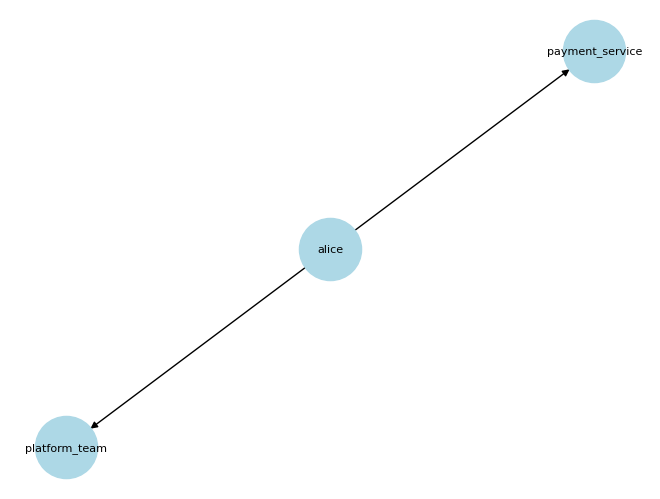

In [8]:
nx.draw(kg.graph, with_labels=True, node_color='lightblue', node_size=2000, font_size=8, arrows=True)
plt.show()